<a href="https://colab.research.google.com/github/victorm0202/temas_selectos_CD_2026/blob/main/Notebooks/1-5.%20RNNs%20for%20Text%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de noticias con redes recurrentes

Clasificamos noticias en cuatro categorías con PyTorch y comparamos cinco arquitecturas: RNN simple, RNN apilada y tres variantes de LSTM.

Cada modelo convierte los índices de los tokens en vectores (*embeddings*) de 50 componentes, procesa la secuencia con capas recurrentes y produce cuatro puntuaciones de clase mediante una capa lineal. Los embeddings se aprenden durante el entrenamiento.

Ejecuta las secciones en orden: comparten funciones y datos, y algunas redefinen las clases de los modelos.

# Bibliotecas y dispositivo de cómputo

Importamos NumPy, PyTorch, la función de carga de datos y las barras de progreso. Seleccionamos MPS si está disponible en macOS; en otros sistemas, CUDA si está disponible. En caso contrario, usamos CPU.

In [ ]:
#!pip install -q datasets
import numpy as np
import torch
from datasets import load_dataset
from tqdm.notebook import tqdm

In [ ]:
import platform
if platform.system() == 'Darwin': #si es macOS
    av1 = torch.backends.mps.is_available()
    # this ensures that the current PyTorch installation was built with MPS activated.
    av2 = torch.backends.mps.is_built()
    if(av1==av2==True):
        print('MPS available?',av1,'MPS built?',av2)
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
else:
    #Check if GPU is available
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
print("Device:",device)

MPS available? True MPS built? True
Device: mps


# Conjunto de datos

Cargamos **AG NEWS** desde Hugging Face Datasets, con sus particiones de entrenamiento y prueba. Las etiquetas de 0 a 3 corresponden a noticias internacionales (`World`), deportes (`Sports`), negocios (`Business`) y ciencia y tecnología (`Sci/Tech`).

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

raw_dataset = load_dataset("ag_news")
raw_train_dataset = raw_dataset["train"]
raw_test_dataset = raw_dataset["test"]

In [ ]:
type(raw_train_dataset)

datasets.arrow_dataset.Dataset

## Tokenización y vocabulario

Convertimos el texto a minúsculas y lo separamos en tokens mediante una expresión regular que reconoce palabras, números y signos de puntuación. Construimos el vocabulario solo con los textos de entrenamiento, conservando todos los tokens observados y ordenándolos por frecuencia.

Reservamos el índice 0 para relleno (`<PAD>`) y el 1 para tokens desconocidos (`<UNK>`). La clase `Vocab` permite convertir una secuencia de tokens en índices; después comprobamos la conversión con una frase.

In [ ]:
import re
from collections import Counter

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1

_token_pattern = re.compile(r"[a-z0-9]+(?:'[a-z]+)?|[^\w\s]", re.IGNORECASE)

def tokenizer(text):
    return _token_pattern.findall(text.lower())


class Vocab:
    def __init__(self, counter, specials=(PAD_TOKEN, UNK_TOKEN), min_freq=1):
        self.itos = list(specials)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

        for token, freq in counter.most_common():
            if freq >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, UNK_IDX)

    def __call__(self, tokens):
        return [self[token] for token in tokens]


counter = Counter()
for text in raw_train_dataset["text"]:
    counter.update(tokenizer(text))

vocab = Vocab(counter, min_freq=1)

In [ ]:
len(vocab)

67686

In [ ]:
tokens = tokenizer("Hello how are you?")
indexes = vocab(tokens)

tokens, indexes

(['hello', 'how', 'are', 'you', '?'], [12528, 394, 54, 203, 96])

# Conversión de textos a tensores

Representamos cada noticia con `max_words = 25` índices de tokens: recortamos las secuencias largas y completamos las cortas con ceros al final. Esta longitud es un hiperparámetro.

`make_tensor_dataset` crea un `TensorDataset` con los textos codificados y sus etiquetas. Ambos se almacenan como tensores de enteros en CPU.

In [ ]:
max_words = 25
target_classes = ["World", "Sports", "Business", "Sci/Tech"]

def encode_text(text, max_words):
    token_ids = vocab(tokenizer(text))[:max_words]
    padding = [PAD_IDX] * (max_words - len(token_ids))
    return token_ids + padding

def make_tensor_dataset(dataset, max_words):
    # El dataset se mantiene en CPU; cada batch se mueve a `device`
    # dentro de TrainModel, CalcValLossAndAccuracy y MakePredictions.
    X = torch.tensor(
        [encode_text(text, max_words) for text in dataset["text"]],
        dtype=torch.long
    )
    Y = torch.tensor(dataset["label"], dtype=torch.long)
    return TensorDataset(X, Y)

train_dataset = make_tensor_dataset(raw_train_dataset, max_words)
test_dataset = make_tensor_dataset(raw_test_dataset, max_words)

## Data loaders

Los `DataLoader` agrupan hasta 1024 noticias por lote y mezclan el orden del conjunto de entrenamiento. Cada lote contiene textos de forma `(B, max_words)` y etiquetas de forma `(B,)`, donde `B` es el número de ejemplos del lote.

Activamos `pin_memory` cuando usamos CUDA. Las funciones de entrenamiento y evaluación trasladan cada lote al dispositivo seleccionado.

In [ ]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    pin_memory=pin_memory
)

In [ ]:
len(train_dataset)

120000

In [ ]:
for X, Y in train_loader:
    print(X.shape, Y.shape)
    break

torch.Size([1024, 25]) torch.Size([1024])


# RNN de una capa

El modelo procesa cada lote en tres pasos:

1. **Embedding:** transforma los índices `(B, 25)` en vectores `(B, 25, 50)`.
2. **RNN:** recorre los 25 pasos y genera un estado de 50 componentes por paso. `batch_first=True` mantiene el lote como primera dimensión.
3. **Capa lineal:** recibe `output[:, -1]`, de forma `(B, 50)`, y devuelve cuatro puntuaciones sin normalizar (*logits*) por noticia.

El estado inicial se genera aleatoriamente en cada llamada a `forward`, incluso al evaluar. Se usa la última posición de la secuencia, que puede corresponder a relleno; el código no omite esos pasos.

In [ ]:
from torch import nn
from torch.nn import functional as F

embed_len = 50
hidden_dim = 50
n_layers=1

class RNNClassifier(nn.Module):
    def __init__(self):
        super(RNNClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_len)
        self.rnn = nn.RNN(input_size=embed_len, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, len(target_classes))

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        embedding = embeddings.to(device)
        output, hidden = self.rnn(embeddings, torch.randn(n_layers, len(X_batch), hidden_dim).to(device))
        return self.linear(output[:,-1])

## Comprobación de dimensiones

Creamos el modelo, lo trasladamos a `device` e inspeccionamos las dimensiones de sus parámetros. Una pasada con índices aleatorios comprueba que la salida tenga forma `(1024, 4)`; todavía no evalúa la calidad de las predicciones.

In [ ]:
rnn_classifier = RNNClassifier()
rnn_classifier.to(device)
rnn_classifier

RNNClassifier(
  (embedding_layer): Embedding(67686, 50)
  (rnn): RNN(50, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=4, bias=True)
)

In [ ]:
for layer in rnn_classifier.children():
    print("Layer : {}".format(layer))
    print("Parameters : ")
    for param in layer.parameters():
        print(param.shape)
    print()

Layer : Embedding(67686, 50)
Parameters : 
torch.Size([67686, 50])

Layer : RNN(50, 50, batch_first=True)
Parameters : 
torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50])
torch.Size([50])

Layer : Linear(in_features=50, out_features=4, bias=True)
Parameters : 
torch.Size([4, 50])
torch.Size([4])



In [ ]:
temp = torch.randint(0, len(vocab), (1024, max_words)).to(device)
out = rnn_classifier(temp)
out.shape

torch.Size([1024, 4])

## Entrenamiento y evaluación

`TrainModel` calcula la entropía cruzada, reinicia los gradientes y actualiza los parámetros con Adam. Entrenamos durante 15 épocas con tasa de aprendizaje `0.001`.

Al final de cada época, `CalcValLossAndAccuracy` evalúa sin calcular gradientes y muestra la pérdida media por lote. Aunque la función habla de validación, aquí recibe el conjunto de prueba; la impresión de exactitud está comentada.

Después, `MakePredictions` selecciona la clase con mayor probabilidad. Calculamos la exactitud global, la precisión, la exhaustividad y F1 por clase, y una matriz de confusión con conteos: filas para clases reales y columnas para predicciones.

In [ ]:
from sklearn.metrics import accuracy_score
import gc

def CalcValLossAndAccuracy(model, loss_fn, val_loader):
    with torch.no_grad():
        Y_shuffled, Y_preds, losses = [],[],[]
        for X, Y in tqdm(val_loader):
            X = X.to(device)
            Y = Y.to(device)
            preds = model(X)
            loss = loss_fn(preds, Y)
            losses.append(loss.item())

            Y_shuffled.append(Y)
            Y_preds.append(preds.argmax(dim=-1))

        Y_shuffled = torch.cat(Y_shuffled)
        Y_preds = torch.cat(Y_preds)

        print("Valid Loss : {:.3f}".format(torch.tensor(losses).mean()))
        #print("Valid Acc  : {:.3f}".format(accuracy_score(Y_shuffled.detach().cpu().numpy(), Y_preds.detach().cpu().numpy())))


def TrainModel(model, loss_fn, optimizer, train_loader, val_loader, epochs=10):
    for i in range(1, epochs+1):
        losses = []
        for X, Y in tqdm(train_loader):
            X = X.to(device)
            Y = Y.to(device)
            Y_preds = model(X)

            loss = loss_fn(Y_preds, Y)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
        CalcValLossAndAccuracy(model, loss_fn, val_loader)


In [ ]:
from torch.optim import Adam

epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
rnn_classifier = RNNClassifier()
# Send model to `device` (GPU/CPU)
rnn_classifier.to(device)
optimizer = Adam(rnn_classifier.parameters(), lr=learning_rate)

TrainModel(rnn_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.334


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 1.162


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.414


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.239


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.410


In [ ]:
def MakePredictions(model, loader):
    Y_shuffled, Y_preds = [], []
    for X, Y in loader:
        X = X.to(device)
        Y = Y.to(device)
        preds = model(X)
        Y_preds.append(preds)
        Y_shuffled.append(Y)
    gc.collect()
    Y_preds, Y_shuffled = torch.cat(Y_preds), torch.cat(Y_shuffled)

    return Y_shuffled.detach().cpu().numpy(), F.softmax(Y_preds, dim=-1).argmax(dim=-1).detach().cpu().numpy()


In [ ]:
Y_actual, Y_preds = MakePredictions(rnn_classifier, test_loader)

Test Accuracy : 0.8718421052631579

Classification Report : 
              precision    recall  f1-score   support

       World       0.88      0.88      0.88      1900
      Sports       0.92      0.95      0.93      1900
    Business       0.85      0.82      0.84      1900
    Sci/Tech       0.84      0.84      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



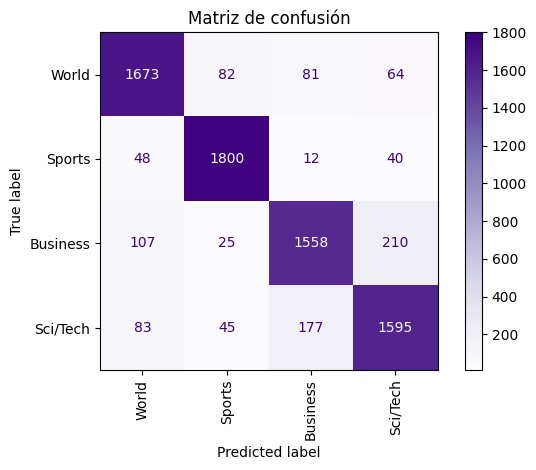

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# RNN de tres capas

Ampliamos las secuencias a 50 tokens y reconstruimos los tensores y los cargadores. El modelo apila tres capas RNN de 50 unidades, con embeddings de 50 componentes.

`padding_idx=PAD_IDX` mantiene fijo el embedding de relleno, aunque la RNN sigue procesando esas posiciones. Inicializamos aleatoriamente los estados de las tres capas y clasificamos con la última salida de la capa superior. Después inspeccionamos los parámetros y comprobamos las dimensiones de salida.

In [ ]:
max_words = 50

train_dataset = make_tensor_dataset(raw_train_dataset, max_words)
test_dataset = make_tensor_dataset(raw_test_dataset, max_words)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    pin_memory=pin_memory
)

In [ ]:
for X, Y in train_loader:
    print(X.shape, Y.shape)
    break

torch.Size([1024, 50]) torch.Size([1024])


In [ ]:
embed_len = 50
hidden_dim = 50
n_layers=3

class RNNClassifier(nn.Module):
    def __init__(self):
        super(RNNClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_len, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(input_size=embed_len, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, len(target_classes))

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        embedding = embeddings.to(device)
        output, hidden = self.rnn(embeddings, torch.randn(n_layers, len(X_batch), hidden_dim).to(device))
        return self.linear(output[:,-1])

In [ ]:
rnn_classifier = RNNClassifier()
rnn_classifier.to(device)
rnn_classifier

RNNClassifier(
  (embedding_layer): Embedding(67686, 50, padding_idx=0)
  (rnn): RNN(50, 50, num_layers=3, batch_first=True)
  (linear): Linear(in_features=50, out_features=4, bias=True)
)

In [ ]:
for layer in rnn_classifier.children():
    print("Layer : {}".format(layer))
    print("Parameters : ")
    for param in layer.parameters():
        print(param.shape)
    print()

Layer : Embedding(67686, 50, padding_idx=0)
Parameters : 
torch.Size([67686, 50])

Layer : RNN(50, 50, num_layers=3, batch_first=True)
Parameters : 
torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50])
torch.Size([50])
torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50])
torch.Size([50])
torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50])
torch.Size([50])

Layer : Linear(in_features=50, out_features=4, bias=True)
Parameters : 
torch.Size([4, 50])
torch.Size([4])



In [ ]:
temp = torch.randint(0, len(vocab), (1024, max_words)).to(device)
out = rnn_classifier(temp)
out.shape

torch.Size([1024, 4])

## Entrenamiento y evaluación

Entrenamos la RNN apilada durante 15 épocas con Adam, tasa `0.001` y entropía cruzada. Reutilizamos las funciones anteriores y mostramos la exactitud, el informe por clase y la matriz de confusión del conjunto de prueba.

Al comparar con la primera RNN, considera que cambiaron tanto la profundidad como la longitud de entrada: de 25 a 50 tokens.

In [ ]:
from torch.optim import Adam

epochs = 15
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
rnn_classifier = RNNClassifier()
# Send model to `device` (GPU/CPU)
rnn_classifier.to(device)
optimizer = Adam(rnn_classifier.parameters(), lr=learning_rate)

TrainModel(rnn_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.306


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 1.129


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.385


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.298


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.400


Test Accuracy : 0.8744736842105263

Classification Report : 
              precision    recall  f1-score   support

       World       0.88      0.86      0.87      1900
      Sports       0.95      0.92      0.94      1900
    Business       0.84      0.83      0.84      1900
    Sci/Tech       0.82      0.89      0.85      1900

    accuracy                           0.87      7600
   macro avg       0.88      0.87      0.87      7600
weighted avg       0.88      0.87      0.87      7600



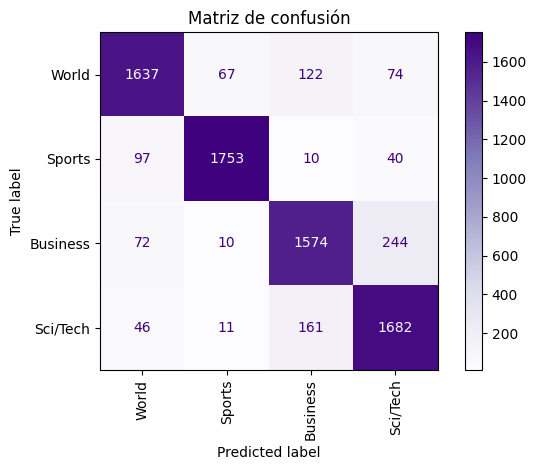

In [ ]:
Y_actual, Y_preds = MakePredictions(rnn_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# LSTM de tres capas

Usamos secuencias de 50 tokens, embeddings de 50 componentes y tres capas LSTM de 75 unidades. La LSTM mantiene un estado oculto (`hidden`) y un estado de memoria (`carry`); el código inicializa ambos aleatoriamente en cada pasada.

La salida tiene forma `(B, 50, 75)`. La capa lineal transforma la última posición en cuatro logits por noticia. Creamos el modelo y comprobamos las dimensiones de sus parámetros y de su salida.

In [ ]:
max_words = 50

train_dataset = make_tensor_dataset(raw_train_dataset, max_words)
test_dataset = make_tensor_dataset(raw_test_dataset, max_words)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    pin_memory=pin_memory
)

In [ ]:
embed_len = 50
hidden_dim = 75
n_layers=3

class LSTMClassifier(nn.Module):
    def __init__(self):
        super(LSTMClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_len, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(input_size=embed_len, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, len(target_classes))

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        embeddings = embeddings.to(device)
        hidden, carry = torch.randn(n_layers, len(X_batch), hidden_dim), torch.randn(n_layers, len(X_batch), hidden_dim)
        output, (hidden, carry) = self.lstm(embeddings, (hidden.to(device), carry.to(device)))
        return self.linear(output[:,-1])

In [ ]:
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
lstm_classifier

LSTMClassifier(
  (embedding_layer): Embedding(67686, 50, padding_idx=0)
  (lstm): LSTM(50, 75, num_layers=3, batch_first=True)
  (linear): Linear(in_features=75, out_features=4, bias=True)
)

In [ ]:
for layer in lstm_classifier.children():
    print("Layer : {}".format(layer))
    print("Parameters : ")
    for param in layer.parameters():
        print(param.shape)
    print()

Layer : Embedding(67686, 50, padding_idx=0)
Parameters : 
torch.Size([67686, 50])

Layer : LSTM(50, 75, num_layers=3, batch_first=True)
Parameters : 
torch.Size([300, 50])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 75])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 75])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])

Layer : Linear(in_features=75, out_features=4, bias=True)
Parameters : 
torch.Size([4, 75])
torch.Size([4])



In [ ]:
temp = torch.randint(0, len(vocab), (1024, max_words)).to(device)
out = lstm_classifier(temp)
out.shape

torch.Size([1024, 4])

## Entrenamiento y evaluación

Entrenamos la LSTM durante 10 épocas con Adam, tasa `0.001` y entropía cruzada. Después calculamos la exactitud, el informe por clase y la matriz de confusión sobre el conjunto de prueba.

In [ ]:
epochs = 10
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
optimizer = Adam(lstm_classifier.parameters(), lr=learning_rate)

TrainModel(lstm_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.154


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.852


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.314


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.204


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.321


Test Accuracy : 0.8922368421052631

Classification Report : 
              precision    recall  f1-score   support

       World       0.90      0.89      0.89      1900
      Sports       0.93      0.97      0.95      1900
    Business       0.87      0.84      0.85      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



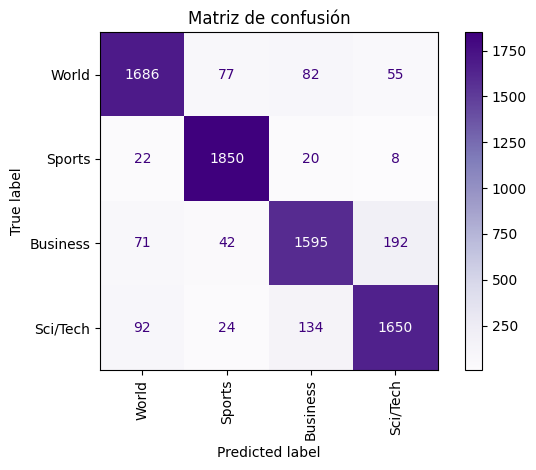

In [ ]:
Y_actual, Y_preds = MakePredictions(lstm_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# LSTM apiladas con distintos tamaños

Mantenemos 50 tokens por noticia y embeddings de 50 componentes. Conectamos tres módulos LSTM de una capa, con 50, 60 y 75 unidades, respectivamente.

Cada LSTM recibe la secuencia completa de salidas de la anterior. Las dimensiones pasan de `(B, 50, 50)` a `(B, 50, 60)` y luego a `(B, 50, 75)`.

Cada módulo tiene sus propios estados oculto y de memoria, inicializados aleatoriamente en cada pasada. La capa lineal usa la última posición de la tercera LSTM para producir los cuatro logits. Después comprobamos las dimensiones del modelo.

In [ ]:
max_words = 50

train_dataset = make_tensor_dataset(raw_train_dataset, max_words)
test_dataset = make_tensor_dataset(raw_test_dataset, max_words)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    pin_memory=pin_memory
)

In [ ]:
embed_len = 50
hidden_dim1 = 50
hidden_dim2 = 60
hidden_dim3 = 75
n_layers=1

class LSTMClassifier(nn.Module):
    def __init__(self):
        super(LSTMClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_len, padding_idx=PAD_IDX)
        self.lstm1 = nn.LSTM(input_size=embed_len, hidden_size=hidden_dim1, num_layers=1, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=hidden_dim1, hidden_size=hidden_dim2, num_layers=1, batch_first=True)
        self.lstm3 = nn.LSTM(input_size=hidden_dim2, hidden_size=hidden_dim3, num_layers=1, batch_first=True)
        self.linear = nn.Linear(hidden_dim3, len(target_classes))

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        embeddings = embeddings.to(device)
        hidden, carry = torch.randn(n_layers, len(X_batch), hidden_dim1), torch.randn(n_layers, len(X_batch), hidden_dim1)
        output, (hidden, carry) = self.lstm1(embeddings, (hidden.to(device), carry.to(device)))

        hidden, carry = torch.randn(n_layers, len(X_batch), hidden_dim2), torch.randn(n_layers, len(X_batch), hidden_dim2)
        output, (hidden, carry) = self.lstm2(output, (hidden.to(device), carry.to(device)))

        hidden, carry = torch.randn(n_layers, len(X_batch), hidden_dim3), torch.randn(n_layers, len(X_batch), hidden_dim3)
        output, (hidden, carry) = self.lstm3(output, (hidden.to(device), carry.to(device)))
        return self.linear(output[:,-1])

In [ ]:
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
lstm_classifier

LSTMClassifier(
  (embedding_layer): Embedding(67686, 50, padding_idx=0)
  (lstm1): LSTM(50, 50, batch_first=True)
  (lstm2): LSTM(50, 60, batch_first=True)
  (lstm3): LSTM(60, 75, batch_first=True)
  (linear): Linear(in_features=75, out_features=4, bias=True)
)

In [ ]:
for layer in lstm_classifier.children():
    print("Layer : {}".format(layer))
    print("Parameters : ")
    for param in layer.parameters():
        print(param.shape)
    print()

Layer : Embedding(67686, 50, padding_idx=0)
Parameters : 
torch.Size([67686, 50])

Layer : LSTM(50, 50, batch_first=True)
Parameters : 
torch.Size([200, 50])
torch.Size([200, 50])
torch.Size([200])
torch.Size([200])

Layer : LSTM(50, 60, batch_first=True)
Parameters : 
torch.Size([240, 50])
torch.Size([240, 60])
torch.Size([240])
torch.Size([240])

Layer : LSTM(60, 75, batch_first=True)
Parameters : 
torch.Size([300, 60])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])

Layer : Linear(in_features=75, out_features=4, bias=True)
Parameters : 
torch.Size([4, 75])
torch.Size([4])



In [ ]:
temp = torch.randint(0, len(vocab), (1024, max_words)).to(device)
out = lstm_classifier(temp)
out.shape

torch.Size([1024, 4])

## Entrenamiento y evaluación

Entrenamos las tres LSTM conectadas durante 10 épocas con Adam, tasa `0.001` y entropía cruzada. Evaluamos con la misma exactitud, informe por clase y matriz de confusión para comparar con la LSTM de tamaño uniforme.

In [ ]:
epochs = 10
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
optimizer = Adam(lstm_classifier.parameters(), lr=learning_rate)

TrainModel(lstm_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.133


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.826


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.317


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.209


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.318


Test Accuracy : 0.8923684210526316

Classification Report : 
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.94      0.96      0.95      1900
    Business       0.91      0.80      0.85      1900
    Sci/Tech       0.82      0.92      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



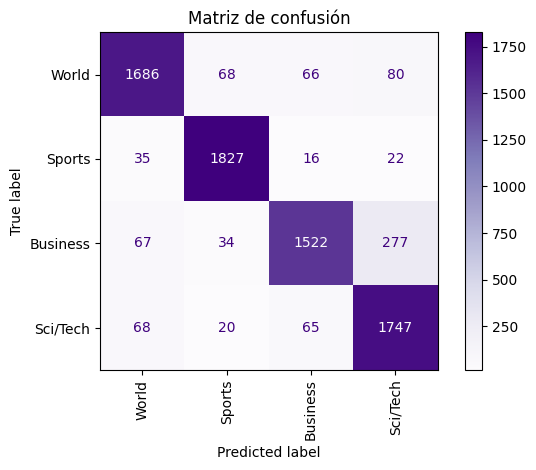

In [ ]:
Y_actual, Y_preds = MakePredictions(lstm_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# LSTM bidireccional de tres capas

Procesamos secuencias de 50 tokens con embeddings de 50 componentes. Cada una de las tres capas LSTM recorre la secuencia en ambos sentidos, con 75 unidades por dirección. Al concatenarlas, la salida tiene forma `(B, 50, 150)`.

Los estados iniciales aleatorios tienen forma `(6, B, 75)`: tres capas por dos direcciones. La capa lineal recibe los 150 componentes de `output[:, -1]` y produce cuatro logits.

Esta selección toma ambas direcciones en la última posición; no reúne los estados finales de ambos recorridos. Comprobamos también las dimensiones de los parámetros y de la salida.

In [ ]:
max_words = 50

train_dataset = make_tensor_dataset(raw_train_dataset, max_words)
test_dataset = make_tensor_dataset(raw_test_dataset, max_words)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    pin_memory=pin_memory
)

In [ ]:
embed_len = 50
hidden_dim = 75
n_layers=3

class LSTMClassifier(nn.Module):
    def __init__(self):
        super(LSTMClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_len, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(input_size=embed_len, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True,
                            bidirectional=True)
        ## Input dimension are 2 times hidden dimensions due to bidirectional results
        self.linear = nn.Linear(2*hidden_dim, len(target_classes))

    def forward(self, X_batch):
        embeddings = self.embedding_layer(X_batch)
        embeddings = embeddings.to(device)
        hidden, carry = torch.randn(2*n_layers, len(X_batch), hidden_dim), torch.randn(2*n_layers, len(X_batch), hidden_dim)
        output, (hidden, carry) = self.lstm(embeddings, (hidden.to(device), carry.to(device)))
        return self.linear(output[:,-1])

In [ ]:
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
lstm_classifier

LSTMClassifier(
  (embedding_layer): Embedding(67686, 50, padding_idx=0)
  (lstm): LSTM(50, 75, num_layers=3, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=150, out_features=4, bias=True)
)

In [ ]:
for layer in lstm_classifier.children():
    print("Layer : {}".format(layer))
    print("Parameters : ")
    for param in layer.parameters():
        print(param.shape)
    print()

Layer : Embedding(67686, 50, padding_idx=0)
Parameters : 
torch.Size([67686, 50])

Layer : LSTM(50, 75, num_layers=3, batch_first=True, bidirectional=True)
Parameters : 
torch.Size([300, 50])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 50])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 150])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 150])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 150])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])
torch.Size([300, 150])
torch.Size([300, 75])
torch.Size([300])
torch.Size([300])

Layer : Linear(in_features=150, out_features=4, bias=True)
Parameters : 
torch.Size([4, 150])
torch.Size([4])



In [ ]:
temp = torch.randint(0, len(vocab), (1024, max_words)).to(device)
out = lstm_classifier(temp)
out.shape

torch.Size([1024, 4])

## Entrenamiento y evaluación

Entrenamos el modelo bidireccional durante 10 épocas con Adam, tasa `0.001` y entropía cruzada. Calculamos la exactitud, el informe por clase y la matriz de confusión con conteos.

La última celda solicita además una matriz normalizada mediante `skplt`, un alias que no se importa en este notebook.

In [ ]:
from torch.optim import Adam

epochs = 10
learning_rate = 1e-3

loss_fn = nn.CrossEntropyLoss()
lstm_classifier = LSTMClassifier()
lstm_classifier.to(device)
optimizer = Adam(lstm_classifier.parameters(), lr=learning_rate)

TrainModel(lstm_classifier, loss_fn, optimizer, train_loader, test_loader, epochs)

  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 1.099


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.796


  0%|          | 0/118 [00:00<?, ?it/s]

...

Valid Loss : 0.319


  0%|          | 0/118 [00:00<?, ?it/s]

Train Loss : 0.187


  0%|          | 0/8 [00:00<?, ?it/s]

Valid Loss : 0.336


Test Accuracy : 0.8935526315789474

Classification Report : 
              precision    recall  f1-score   support

       World       0.87      0.92      0.89      1900
      Sports       0.95      0.95      0.95      1900
    Business       0.86      0.87      0.86      1900
    Sci/Tech       0.90      0.84      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



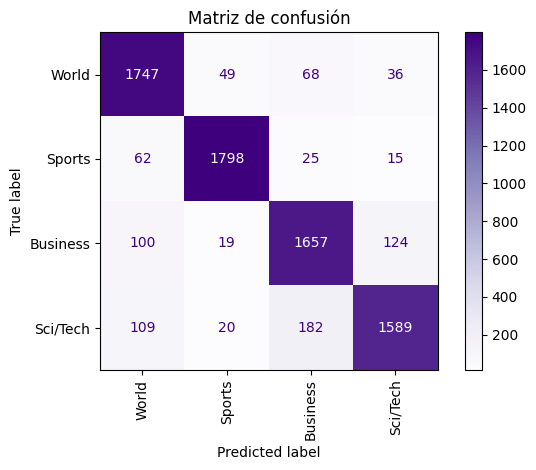

In [ ]:
Y_actual, Y_preds = MakePredictions(lstm_classifier, test_loader)

print("Test Accuracy : {}".format(accuracy_score(Y_actual, Y_preds)))
print("\nClassification Report : ")
print(classification_report(Y_actual, Y_preds, target_names=target_classes))

cm = confusion_matrix(Y_actual, Y_preds, normalize=None)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_classes
)

disp.plot(
    cmap="Purples",
    values_format="d",
    xticks_rotation=90
)

plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

(array([0, 1, 2, 3]), <a list of 4 Text major ticklabel objects>)

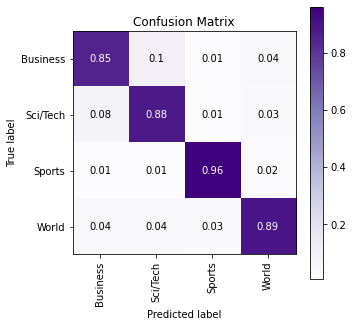

In [ ]:
skplt.metrics.plot_confusion_matrix([target_classes[i] for i in Y_actual], [target_classes[i] for i in Y_preds],
                                    normalize=True,
                                    title="Confusion Matrix",
                                    cmap="Purples",
                                    hide_zeros=True,
                                    figsize=(5,5)
                                    );
plt.xticks(rotation=90)